In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import sys

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from matplotlib.gridspec import GridSpec
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSPlots


In [32]:
PROJECT_ROOT

PosixPath('/home/paulius/vq_vae_experiments')

<h3>Model post-processing study</h3>

Testing pileup ml project neural network methods before integration

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
Path.cwd().parent

PosixPath('/home/paulius/vq_vae_experiments')

In [4]:
from helpers.data_tool import PixelPatchesDataset,\
                                CMSDataTool
from components.vqvae_management.components import CMSVQVAE
from helpers.models import ModelConfig                              

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

In [ ]:
# TODO loaded from json file
# NOTE: Passed externally in a saparate notebook 
config_data = {
    "model_name": "vq_vae",
    "model_folder": "build",
    "batch_size" : 64,
    "beta" : 0.31,
    "learning_rate" : 1e-3,
    "model_param_scale" : 5,
    "num_epochs" : 80,
    "channels" : 1,
    "hidden_channels" : 64,
    "num_embeddings" : 256,
    "kernel_size" : 4,
    "slope" : 0.1,
    "latent_dim" : 32,
    "residual_channels" : 32,
    "residual_layers" : 2
}

In [7]:
cms_data_tool = CMSDataTool()

In [8]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 240.46it/s]


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config_data["device"] = device
device

device(type='cuda')

<h3>Selecting event objects</h3>

In [10]:
event_train = events_train[0]
events_test = events_test[0]

In [11]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [13]:
# Training set pre-processing


event_dataset = PixelPatchesDataset(
    event_train, 
    PATCH_SIZE, 
    transform
)
dataset_size = len(event_dataset)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size
batch_size = 64

train_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

print(f"Training set size: {len(train_dataset)}")

Training set size: 12685


In [34]:
len(list(train_loader)[0])

64

In [14]:
config_data

{'model_name': 'vq_vae',
 'model_folder': 'build',
 'batch_size': 64,
 'beta': 0.31,
 'learning_rate': 0.001,
 'model_param_scale': 5,
 'num_epochs': 80,
 'channels': 1,
 'hidden_channels': 64,
 'num_embeddings': 256,
 'kernel_size': 4,
 'slope': 0.1,
 'latent_dim': 32,
 'residual_channels': 32,
 'residual_layers': 2,
 'device': device(type='cuda')}

In [15]:
config = ModelConfig(**config_data)

In [16]:
cms_vq_vae = CMSVQVAE(
    config=config, 
    train_loader=train_loader
)

In [17]:
print("Performing model training")
cms_vq_vae.fit(verbose=True)

Performing model training


Epoch (0/80) model VQ_LOSS + BCE Loss = 0.183264277351262
Epoch (1/80) model VQ_LOSS + BCE Loss = 0.05855933526278141
Epoch (2/80) model VQ_LOSS + BCE Loss = 0.04896796811091241
Epoch (3/80) model VQ_LOSS + BCE Loss = 0.04536889016104104
Epoch (4/80) model VQ_LOSS + BCE Loss = 0.043536335417074176
Epoch (5/80) model VQ_LOSS + BCE Loss = 0.04209741461441745
Epoch (6/80) model VQ_LOSS + BCE Loss = 0.040756272704307754
Epoch (7/80) model VQ_LOSS + BCE Loss = 0.039776779261965246
Epoch (8/80) model VQ_LOSS + BCE Loss = 0.038923126303745274
Epoch (9/80) model VQ_LOSS + BCE Loss = 0.038786138403206015
Epoch (10/80) model VQ_LOSS + BCE Loss = 0.038436629973239635
Epoch (11/80) model VQ_LOSS + BCE Loss = 0.03780230642974976
Epoch (12/80) model VQ_LOSS + BCE Loss = 0.03713470445618258
Epoch (13/80) model VQ_LOSS + BCE Loss = 0.0368069202437922
Epoch (14/80) model VQ_LOSS + BCE Loss = 0.03651496572373201
Epoch (15/80) model VQ_LOSS + BCE Loss = 0.036235891825439945
Epoch (16/80) model VQ_LOSS + 

In [18]:
cms_vq_vae.display_gradients()

Showing model gradients
encoder.0.weight 0.016469847410917282
encoder.1.weight 0.0024953570682555437
encoder.1.bias 0.005470289848744869
encoder.3.weight 0.033344052731990814
encoder.4.weight 0.0020451240707188845
encoder.4.bias 0.0023630906362086535
encoder.6.weight 0.04195709526538849
encoder.7.weight 0.006457500159740448
encoder.7.bias 0.007880918681621552
encoder.8.stack.0.res_block.1.weight 0.010906614363193512
encoder.8.stack.0.res_block.3.weight 0.01648118533194065
encoder.8.stack.1.res_block.1.weight 0.010427821427583694
encoder.8.stack.1.res_block.3.weight 0.00998798105865717
vq_layer.embedding.weight 0.0007199423271231353
decoder.0.weight 0.016024714335799217
decoder.1.weight 0.0025370954535901546
decoder.1.bias 0.0019975777249783278
decoder.2.stack.0.res_block.1.weight 0.00531761022284627
decoder.2.stack.0.res_block.3.weight 0.0077102952636778355
decoder.2.stack.1.res_block.1.weight 0.004843197297304869
decoder.2.stack.1.res_block.3.weight 0.005737843457609415
decoder.3.weig

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


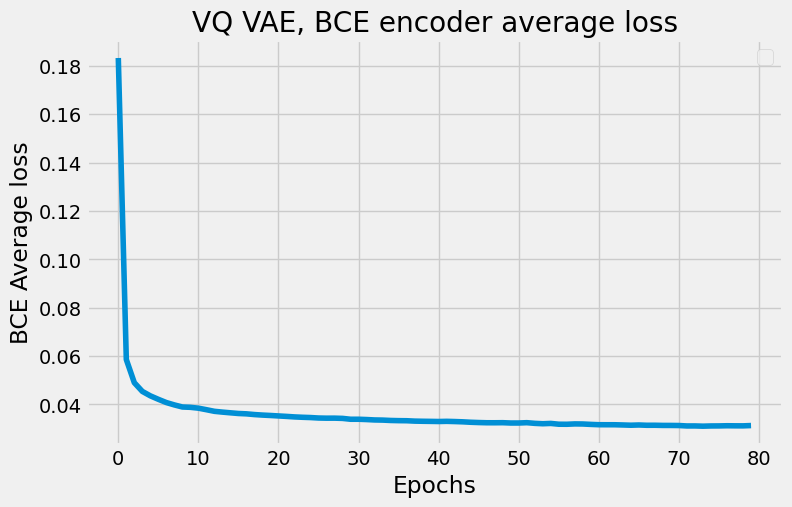

In [19]:
cms_vq_vae.plot_curve("vq_loss")

VQ VAE, Perplexity average across epochs values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


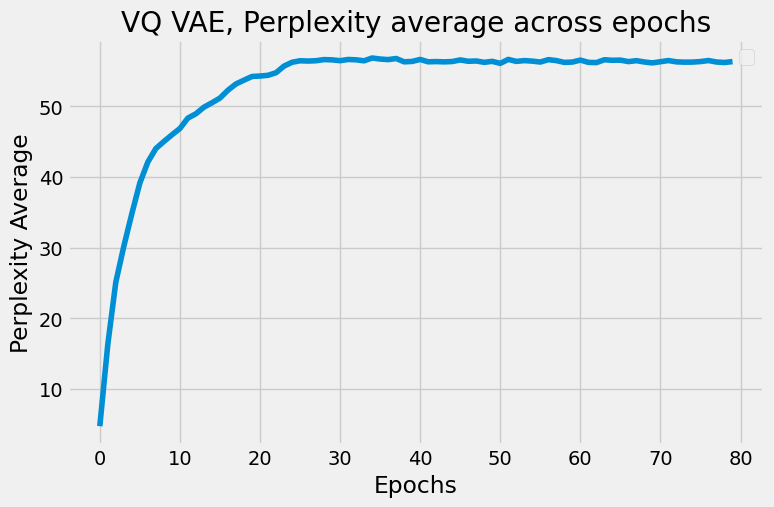

In [20]:
cms_vq_vae.plot_curve("perplexity")

<h3>VQ-VAE testing with test data</h3>

In [21]:
cms_vq_vae.load_model()

SUCCESS: Model loaded from path: build/vq_vae.pth


In [22]:
len(events_test)

24791

In [23]:
event_test_before = []
event_test_encoded = []
event_test_after = []

In [24]:
event_dataset = PixelPatchesDataset(
    events_test, 
    PATCH_SIZE, 
    transform
)
event_dataset_size = int(0.1 * len(event_dataset))
remaining = len(event_dataset) - event_dataset_size

event_test_small, _ = random_split(
    event_dataset,
    [event_dataset_size, remaining]
)

event_loader = DataLoader(
    dataset=event_test_small,
    batch_size=32
)

In [25]:
first_batch = next(iter(event_loader))

In [26]:
model_tool = ModelTool()
DISPLAY_LIMIT = 10

In [ ]:
# TODO: debug plotting patch
for patch in first_batch:
    patch = patch.float()
    patch = patch.to(device)
    patch = patch.unsqueeze(0)
    patch_np = model_tool._tensor_to_numpy(patch[0][0])
    perplexity, encoder_vq_output = cms_vq_vae.transform(patch)
    
    encoder_vq_output_np = model_tool._tensor_to_numpy(
        encoder_vq_output[0][0]
    )
    decoder_vq_output = cms_vq_vae.inverse_transform(encoder_vq_output)
    decoder_vq_output_np = model_tool._tensor_to_numpy(
        decoder_vq_output[0][0]
    )
    
    if len(event_test_before) < DISPLAY_LIMIT:
        event_test_before.append(patch_np)
        event_test_encoded.append(encoder_vq_output_np)
        event_test_after.append(decoder_vq_output_np)

if len(event_test_before) >= DISPLAY_LIMIT:
    print(f"Selected {len(event_test_before)} patches for analysis")
    
print(f"SUCCESS: Model testing completed with perplexity = {perplexity}")
    

Selected 10 patches for analysis


In [28]:
decoder_vq_output_np.shape

(8, 8)

In [29]:
# for patch in event_test_after:
#     cms_plots.plot_patch(patch[0][0], title="Reconstructed patch (Test)")

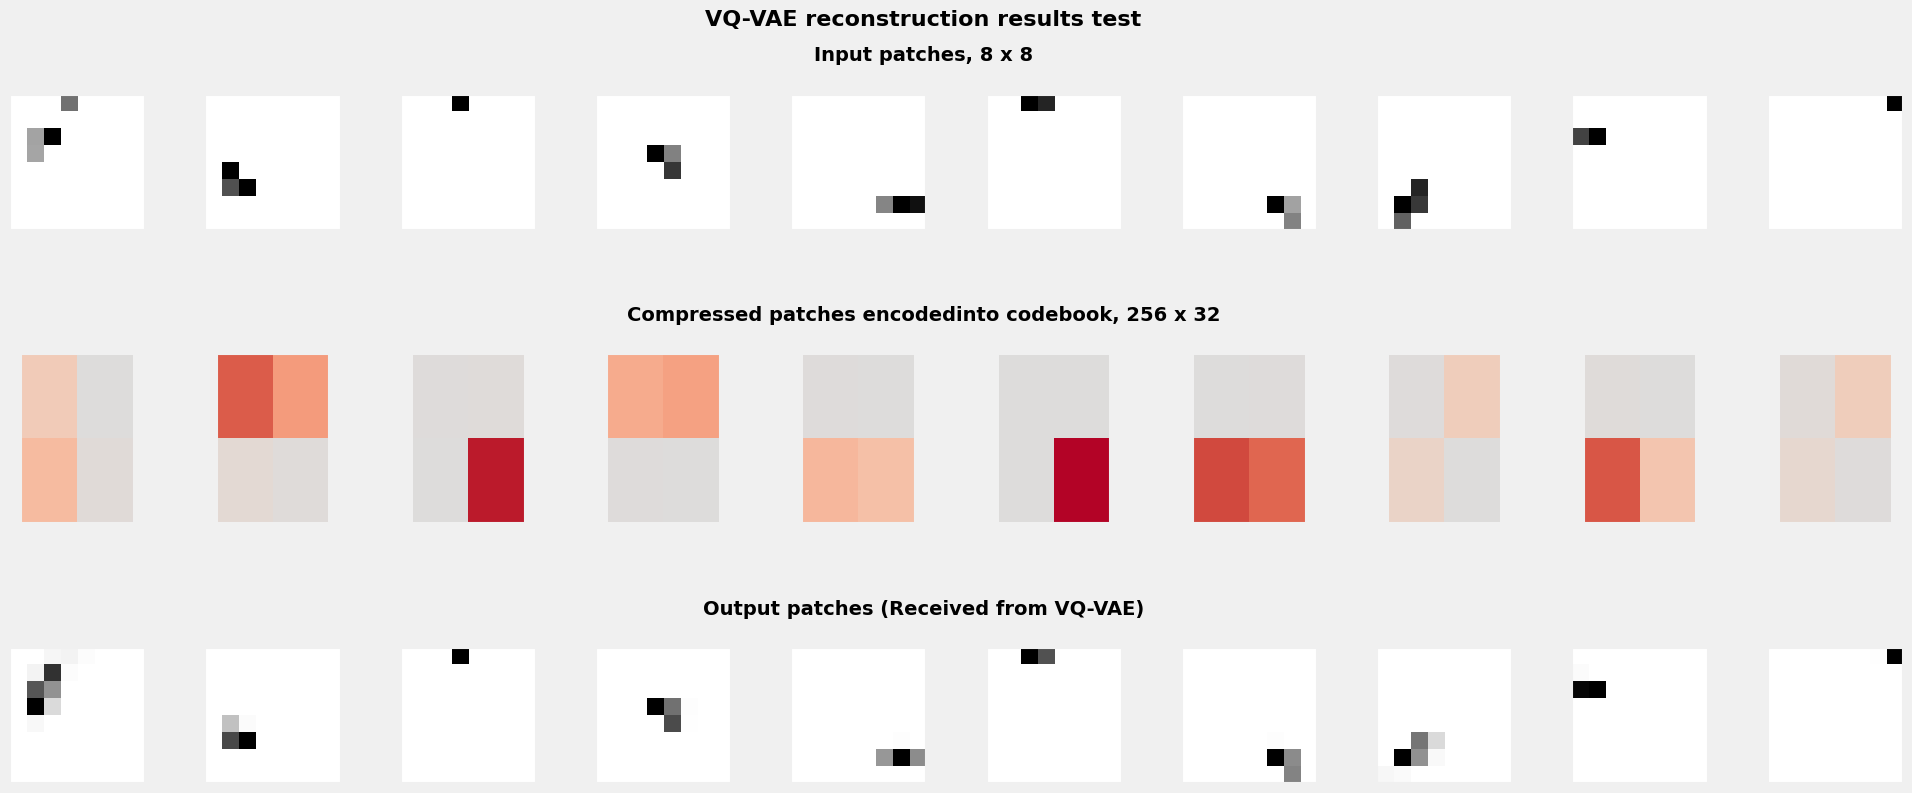

In [30]:
# Test dataset plotting part
patch_rows = [
    (event_test_before, "Input patches, 8 x 8"),
    (event_test_encoded, f"Compressed patches encoded"
     f"into codebook, {config.num_embeddings} x {config.latent_dim}"),
    (event_test_after, "Output patches (Received from VQ-VAE)")
]
cms_plots = CMSPlots()
cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results test",
    codebook=False
)

In [31]:
event_test_encoded[0].shape

(2, 2)